In [1]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.colors import sample_colorscale

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


In [3]:
output_dir = "./outputs/experimental/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="WARNING")

In [4]:
animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [5]:
session_dirs, _ = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)
session_names = fullfnames2snames(session_dirs)

In [6]:
fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr = fr_raw.drop("from_ephys_timestamp", axis=1)
fr.index = fr.index.droplevel((0,1,3, ))
fr.set_index('to_ephys_timestamp', append=True, inplace=True)
fr['global_t'] = np.arange(40_000, 40_000*len(fr)+1, 40_000)
fr.set_index('global_t', append=True, inplace=True)
fr.index = fr.index.rename(['session_id', 'session_t', 'global_t'])
session_t_start = fr.index[fr.index.get_level_values('session_t') == 40_000]

fr = fr.fillna(0)
# fr_z = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std())) # never used

# 
fr

Unit0001  Unit0002  Unit0003  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000               0         0         0   
                 80000      80000               0         0         0   
                 120000     120000              0         0         0   
                 160000     160000              0         0         0   
                 200000     200000              0         0         0   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0         0         0   
                 4436000000 53320520000         0         0         0   
                 4436040000 53320560000         0         0         0   
                 4436080000 53320600000         0         0         0   
                 4436120000 53320640000         0         0         0   

                                         Unit0004  Unit0005  Unit0006  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000               0         0         0   
                 80000      80000               0         0         0   
                 120000     120000              0         0         0   
                 160000     160000              0         0         0   
                 200000     200000              0         0         0   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0         0         0   
                 4436000000 53320520000         0         0         0   
                 4436040000 53320560000         0         0         0   
                 4436080000 53320600000         0         0         0   
                 4436120000 53320640000         0         0         0   

                                         Unit0007  Unit0008  Unit0009  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000               0         0         0   
                 80000      80000               0         0         0   
                 120000     120000              0         0         0   
                 160000     160000              0         0         0   
                 200000     200000              0         0         0   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0         0         0   
                 4436000000 53320520000         0         0         0   
                 4436040000 53320560000         0         0         0   
                 4436080000 53320600000         0         0         0   
                 4436120000 53320640000         0         0         0   

                                         Unit0010  ...  Unit0068  Unit0069  \
session_id       session_t  global_t               ...                       
2024-11-14_16-40 40000      40000               0  ...         0         0   
                 80000      80000               0  ...         0         0   
                 120000     120000              0  ...         0         0   
                 160000     160000              0  ...         0         0   
                 200000     200000              0  ...         0         0   
...                                           ...  ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0  ...        25         0   
                 4436000000 53320520000         0  ...        25         0   
                 4436040000 53320560000         0  ...        25        25   
                 4436080000 53320600000         0  ...        25         0   
                 4436120000 53320640000         0  ...         0         0   

                                         Unit0070  Unit0071  Unit0072  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40

In [7]:
action_enc_cols = [
               'frame_raw_500msMedian', 
               'frame_YawPitch_abs_vel_sum_500msMedian', 
               # acceleration, off rotation
               'frame_raw_abs_acc_500msMedian', 
               'frame_YawPitch_abs_acc_sum_500msMedian', 
               # forward vs rotation correlation
               'forward_vs_rotation_corr',
               # pose estimation based, gengal movement
                "frame_head_angle",
                "frame_head_angle_vel",
                "frame_movement_energy_smooth5",
               # event base actions, lick is frequent
               'lick_detected', ]
state_enc_cols = [
                # position info (track zones integer are ordered like track)
                "track_zone_int", 'cue_visible', # 'frame_postion',
                # event base state changes (alignment needed ideally PSTH aligned to these)
                'reward-sound_detected', 'reward-valve-open_detected',]

behavior_glm_input = analytics.get_analytics('Behavior40msAligned', session_names=session_names,
                                             columns=action_enc_cols+state_enc_cols)
behavior_glm_input.index = behavior_glm_input.index.droplevel(['paradigm_id', 'animal_id']) # drop index level

print("NaN proportion per column:")
display(behavior_glm_input.isna().sum() / len(behavior_glm_input))
display(behavior_glm_input)

# could drop rows that have at least one NaN (20 % because of pose estimation missing data)
# behavior_glm_input = behavior_glm_input.dropna()
# print("Dropping rows with NaN.  New shape:", behavior_glm_input.shape)


NaN proportion per column:


frame_raw_500msMedian                     0.001626
frame_YawPitch_abs_vel_sum_500msMedian    0.001626
frame_raw_abs_acc_500msMedian             0.001626
frame_YawPitch_abs_acc_sum_500msMedian    0.001626
forward_vs_rotation_corr                  0.001626
frame_head_angle                          0.154686
frame_head_angle_vel                      0.157856
frame_movement_energy_smooth5             0.217059
lick_detected                             0.001617
track_zone_int                            0.003410
cue_visible                               0.001617
reward-sound_detected                     0.001617
reward-valve-open_detected                0.001617
dtype: float64

frame_raw_500msMedian  \
session_id       entry_id                          
2024-11-14_16-40 0                           NaN   
                 1                           NaN   
                 2                           NaN   
                 3                           NaN   
                 4                           NaN   
...                                          ...   
2025-01-27_13-39 110898                      NaN   
                 110899                      NaN   
                 110900                      NaN   
                 110901                      NaN   
                 110902                      NaN   

                           frame_YawPitch_abs_vel_sum_500msMedian  \
session_id       entry_id                                           
2024-11-14_16-40 0                                            NaN   
                 1                                            NaN   
                 2                                            NaN   
                 3                                            NaN   
                 4                                            NaN   
...                                                           ...   
2025-01-27_13-39 110898                                       NaN   
                 110899                                       NaN   
                 110900                                       NaN   
                 110901                                       NaN   
                 110902                                       NaN   

                           frame_raw_abs_acc_500msMedian  \
session_id       entry_id                                  
2024-11-14_16-40 0                                   NaN   
                 1                                   NaN   
                 2                                   NaN   
                 3                                   NaN   
                 4                                   NaN   
...                                                  ...   
2025-01-27_13-39 110898                              NaN   
                 110899                              NaN   
                 110900                              NaN   
                 110901                              NaN   
                 110902                              NaN   

                           frame_YawPitch_abs_acc_sum_500msMedian  \
session_id       entry_id                                           
2024-11-14_16-40 0                                            NaN   
                 1                                            NaN   
                 2                                            NaN   
                 3                                            NaN   
                 4                                            NaN   
...                                                           ...   
2025-01-27_13-39 110898                                       NaN   
                 110899                                       NaN   
                 110900                                       NaN   
                 110901                                       NaN   
                 110902                                       NaN   

                           forward_vs_rotation_corr  frame_head_angle  \
session_id       entry_id                                               
2024-11-14_16-40 0                              NaN               NaN   
                 1                              NaN               NaN   
                 2                              NaN               NaN   
                 3                              NaN               NaN   
                 4                              NaN               NaN   
...                                             ...               ...   
2025-01-27_13-39 110898                         NaN               NaN   
                 110899                         NaN               NaN   
                 110900                    

In [8]:
# model quality checking

def poisson_loglik(discrete_counts, lam):
    return np.sum(stats.poisson.logpmf(discrete_counts, lam))

def nb_loglik(discrete_counts, r, p):
    return np.sum(stats.nbinom.logpmf(discrete_counts, r, p))

def aic(loglik, k):
    return 2*k - 2*loglik

def bic(loglik, k, n):
    return k*np.log(n) - 2*loglik

In [9]:
# ==============================================================
# === COMPUTATION UTILITIES ====================================
# ==============================================================

def compute_distribution_params(unit_hz, return_aic=False):
    """
    Compute firing rate statistics and PMFs for Poisson and Negative Binomial.
    Returns dict with mean, std, variance, PMFs, etc.
    """
    m = unit_hz.mean()
    std = unit_hz.std()
    var = std ** 2

    # Convert firing rates to discrete counts
    discrete_counts = np.round(unit_hz.values).astype(int)
    discrete_counts = discrete_counts[discrete_counts >= 0]
    lam = discrete_counts.mean()

    # PMFs
    x = np.arange(0, max(10, discrete_counts.max()) + 1)
    pois_pmf = stats.poisson.pmf(x, lam)

    # Negative binomial params
    p = m / var if var > m else 0.999  # prevent division by zero
    r = m * p / (1 - p)
    nb_pmf = stats.nbinom.pmf(x, r, p)
    
    ll_pois = poisson_loglik(discrete_counts, lam)
    ll_nb   = nb_loglik(discrete_counts, r, p)

    aic_pois = aic(ll_pois, k=1)
    aic_nb   = aic(ll_nb, k=2)
    
    if aic_nb > aic_pois:
        print(f"Negative Binomial not better (AIC_nb={aic_nb:.2f} > AIC_pois={aic_pois:.2f})")

    res = {
        "mean": m,
        "std": std,
        "var": var,
        "lam": lam,
        "x": x,
        "pois_pmf": pois_pmf,
        "nb_pmf": nb_pmf,
    }
    if return_aic:
        res.update({
            # "ll_pois": ll_pois,
            # "ll_nb": ll_nb,
            "aic_pois": aic_pois,
            "aic_nb": aic_nb,
            "aic_r": aic_nb - aic_pois,
            
        })
    return res
    


In [10]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# from scipy import stats


# # ==============================================================
# # === PLOTTING UTILITIES =======================================
# # ==============================================================

# def plot_firing_rate_trace(ax, unit_hz, session_t_start, fr_index, neuron_i):
#     """Plot main firing rate trace with session demarcations."""
#     ax.plot(fr_index.get_level_values('global_t') / (1e6 * 60), unit_hz, alpha=0.7)
#     for i in range(len(session_t_start)):
#         s_id, _, global_t_start = session_t_start[i]
#         global_t_end = (
#             session_t_start[i + 1][2]
#             if i + 1 < len(session_t_start)
#             else fr_index.get_level_values('global_t').max()
#         )
#         avg_fr = unit_hz[
#             (fr_index.get_level_values('global_t') >= global_t_start)
#             & (fr_index.get_level_values('global_t') < global_t_end)
#         ].mean()
#         s_str = f"S{s_id:02}\nAvg {avg_fr:.1f}Hz"
#         ax.axvline(global_t_start / (1e6 * 60), color='gray', linestyle='--', alpha=0.5)
#         ax.text(global_t_start / (1e6 * 60) + 0.1, ax.get_ylim()[1] * 0.9, s_str,
#                 verticalalignment='top', color='gray', alpha=0.7)

#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.set_title(f'Neuron {neuron_i}')
#     ax.set_xlabel('Time (minutes)')
#     ax.set_ylabel('Firing Rate (Hz)')
#     ax.yaxis.set_major_locator(MultipleLocator(25))
#     ax.grid(axis='y', linestyle='--', alpha=0.5)


# def plot_histograms(ax1, ax2, unit_hz, x, nb_pmf, pois_pmf):
#     """Plot histogram + Poisson and NegBinom fits."""
#     # First histogram (log x-scale)
#     ax1.hist(unit_hz, bins=20, orientation='horizontal', color='gray', alpha=0.7, density=True)
#     ax1.plot(nb_pmf, x, 'b--', lw=2)
#     ax1.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)
#     ax1.set_xscale('log')
#     ax1.set_xlabel('Count')
#     ax1.set_ylabel('Firing Rate (Hz)')
#     ax1.yaxis.set_major_locator(MultipleLocator(25))
#     ax1.grid(axis='y', linestyle='--', alpha=0.5)

#     # Second histogram (linear x-scale)
#     bins = ax2.hist(unit_hz, bins=20, orientation='horizontal', color='gray', alpha=0.7, density=True)[0]
#     ax2.plot(nb_pmf, x, 'b--', lw=2, label='NegBinom')
#     ax2.plot(pois_pmf, x, 'r--', lw=2, label='Poisson')
#     ax2.set_xlabel('Density')
#     ax2.set_ylabel('Firing Rate (Hz)')
#     ax2.legend()
#     ax2.yaxis.set_major_locator(MultipleLocator(25))
#     ax2.set_xlim(0, np.max(bins) * 1.2)
#     ax2.grid(axis='y', linestyle='--', alpha=0.5)


# # ==============================================================
# # === MAIN WRAPPER =============================================
# # ==============================================================

# def plot_neuron_summary(fr, session_t_start, neuron_indices=None):
#     """
#     For each neuron, plot firing rate trace and histogram with Poisson/NB fits.
#     """
#     plt.close('all')
#     if neuron_indices is None:
#         neuron_indices = range(fr.shape[1])

#     all_params = []
#     for neuron_i in neuron_indices:
#         fig, ax = plt.subplots(
#             ncols=3, nrows=1, figsize=(40, 3), sharey=False,
#             tight_layout=True, width_ratios=(25, 1, 1)
#         )
#         fig.subplots_adjust(left=0.05, right=0.95)

#         unit_hz = fr.iloc[:, neuron_i]
#         params = compute_distribution_params(unit_hz)
#         all_params.append(params)

#         plot_firing_rate_trace(ax[0], unit_hz, session_t_start, fr.index, neuron_i)
#         plot_histograms(ax[1], ax[2], unit_hz, params["x"], params["nb_pmf"], params["pois_pmf"])

#         # Display summary text
#         m, std = params["mean"], params["std"]
#         ax[2].set_title(f'Mean: {m:.2f}\nSTD: {std:.2f}')

#         if neuron_i > 1:
#             break

#     plt.show()
#     return all_params

# # ==============================================================
# # === EXAMPLE USAGE ============================================
# # ==============================================================


# # Example call (assuming `fr` and `session_t_start` are defined):
# all_params = plot_neuron_summary(fr, session_t_start)
# # or for a subset:
# # plot_neuron_summary(fr, session_t_start, neuron_indices=range(5))


In [11]:
# plt.close('all')
# fig, ax1 = plt.subplots()
# for i, param in enumerate(all_params):
#     x = param["x"]
#     nb_pmf = param["nb_pmf"]
#     cum_nb_pmf = np.cumsum(nb_pmf)
#     # 99% cutoff
#     cutoff_idx = np.where(cum_nb_pmf >= 0.99)[0][0]
#     nb_pmf = nb_pmf[:cutoff_idx+1]
#     x = x[:cutoff_idx+1]

#     # print(nb_pmf)
#     col = 'olive' if i <20 else 'pink'    
#     ax1.plot(x, nb_pmf, col, lw=2, alpha=0.6)
#     ax1.set_yscale('log')
#     ax1.set_ylabel('Density')
#     ax1.set_xlabel('Firing Rate (Hz)')
#     ax1.xaxis.set_major_locator(MultipleLocator(25))
#     ax1.grid(axis='x', linestyle='--', alpha=0.5)
#     ax1.tick_params(axis='y', which='major', labelleft=True)

# plt.show()

In [12]:
def fr_colors(maxval=32):
    """Return Plotly colorscale and a value->color mapper for firing-rate values."""
    eps = 1e-6
    stops = [
        (0, '#ffffff'),
        ((0 + eps) / maxval, "#e8e8e8"),
        (0.1 / maxval, "#e8e8e8"),
        ((0.1 + eps) / maxval, "#8C6565"),
        (1.0 / maxval, "#8C6565"),
        ((1 + eps) / maxval, "#8C6565"),
        (2.0 / maxval, "#8C6565"),
        ((2 + eps) / maxval, "#963F3F"),
        (4.0 / maxval, "#963F3F"),
        ((4 + eps) / maxval, "#A73131"),
        (8.0 / maxval, "#A73131"),
        ((8 + eps) / maxval, "#D1552C"),
        (16.0 / maxval, "#D1552C"),
        ((16 + eps) / maxval, "#D1922C"),
        (32.0 / maxval, "#D1922C"),
    ]

    stops = sorted([(min(max(float(p), 0.0), 1.0), c) for p, c in stops], key=lambda t: t[0])
    colorscale = [[p, c] for p, c in stops]

    def color_fn(value):
        if not np.isfinite(value):
            return "#e8e8e8"
        t = min(max(float(value) / float(maxval), 0.0), 1.0)
        return sample_colorscale(colorscale, [t])[0]

    return colorscale, color_fn


In [13]:

# # ==============================================================
# # === GRID PLOTTING ============================================
# # ==============================================================

# def plot_neuron_session_histograms(fr, session_t_start, neuron_indices=None, n_bins=10):
#     """
#     Plot log(count histograms) for each neuron (rows) and session (columns).
#     Each subplot shows histogram of log firing rates and mean/std in title.
#     """
#     if neuron_indices is None:
#         neuron_indices = range(fr.shape[1])
    
#     session_names = [f"S{s_id:02}" for s_id, _, _ in session_t_start]
#     n_sessions = len(session_names)
#     n_neurons = len(neuron_indices)

#     fig, axes = plt.subplots(
#         nrows=n_neurons, ncols=n_sessions,
#         figsize=(1.4 * n_sessions, 2 * n_neurons),
#         sharex=True, sharey=True
#     )
    
#     cmap, norm = fr_colors(maxval=32)
    
#     # fig.colorbar(im, ax=ax, label='Firing rate (Hz)')

#     # Ensure 2D array of axes
#     if n_neurons == 1:
#         axes = np.expand_dims(axes, 0)
#     if n_sessions == 1:
#         axes = np.expand_dims(axes, 1)

#     fr_index = fr.index.get_level_values('global_t')

#     # Compute start-end time of each session
#     session_boundaries = []
#     for i, (s_id, _, global_t_start) in enumerate(session_t_start):
#         global_t_end = (
#             session_t_start[i + 1][2]
#             if i + 1 < len(session_t_start)
#             else fr_index.max()
#         )
#         session_boundaries.append((s_id, global_t_start, global_t_end))

#     # Iterate neurons × sessions
#     for row, neuron_i in enumerate(neuron_indices):
#         for col, (s_id, t_start, t_end) in enumerate(session_boundaries):
#             ax = axes[row, col]
#             unit_hz = fr.iloc[:, neuron_i]
#             session_mask = (fr_index >= t_start) & (fr_index < t_end)
#             session_data = unit_hz[session_mask]

#             if np.all(session_data == 0):
#                 ax.text(0.5, 0.5, "no spikes", ha='center', va='center', fontsize=8)
#                 # turn off spines
#                 [ax.spines[side].set_visible(False) for side in ['top', 'right', 'left', 'bottom']]
#                 ax.set_xticks([]); ax.set_yticks([])
#                 # axis off
#                 ax.axis('off')
#                 continue

#             params = compute_distribution_params(session_data)

#             x = params["x"]
#             nb_pmf = params["nb_pmf"]
#             pois_pmf = params["pois_pmf"]
#             ax.plot(x, nb_pmf, 'b--', lw=2, label='NegBinom')
#             ax.plot(np.clip(pois_pmf, 1e-22, None), x, 'r--', lw=2)

#             bin_edges = np.arange(0, 301, 25)  # 0–300 Hz in 25 Hz steps
#             ax.hist(session_data, bins=bin_edges, color='gray', alpha=0.6, density=True)

#             m, std = session_data.mean(), session_data.std()
#             # ax.set_title(f"{m:.2f} ± {std:.2f}", fontsize=8)

#             if row == n_neurons - 1:
#                 ax.set_xlabel(session_names[col], fontsize=9)
#             if col == 0:
#                 ax.set_ylabel(f"Neuron {neuron_i}", fontsize=9)
            
#             # draw a dot for firing rate
#             # get max min x y values
#             x_corner, y_corner = 250, 50
#             ax.scatter([x_corner], [y_corner], color=cmap(norm(m)), s=300, 
#                        edgecolor='k', linewidth=.5, zorder=3)
#             ax.text(x_corner-60, y_corner, f"{m:.2}Hz", ha='right', va='center',
#             # ax.text(x_corner-60, y_corner, f"{m:.2}Hz\nAIC_nb={params['aic_nb']:,}\nAIC_p={params['aic_pois']:,}", ha='right', va='center',
#                     fontsize=8)
            
#             sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
            
#             # add thin vertical lines every 100, 200, 300 Hz
#             # [ax.axvline(x, linestyle='-', linewidth=.5, color='k', alpha=.2) 
#             #  for x in (100,200,300)]
            
#             # set ticks at the 25 Hz grid and format as integer labels
#             ax.xaxis.set_major_locator(MultipleLocator(25))
#             ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
#             plt.setp(ax.xaxis.get_ticklabels(), rotation=0, fontsize=8)
#             plt.setp(ax.yaxis.get_ticklabels(), rotation=0, fontsize=8)
#             ax.spines['top'].set_visible(False)
#             ax.spines['right'].set_visible(False)
#             ax.grid(axis='x', linestyle='--', alpha=0.4)
#             ax.grid(False, axis='y')
#             ax.set_yscale('log')
            
            

#     plt.tight_layout()
#     # fig.colorbar(sm, ax=ax, label='Firing rate (Hz)')

# # Example usage (unchanged)
# # set of 5 neurons 
# plt.close("all")
# for neuron_i in range(0,5,5):
#     plot_neuron_session_histograms(fr, session_t_start, neuron_indices=range(neuron_i,neuron_i+5))
#     plt.show()

In [14]:
# # Verify results
# print("Original lick events:", behavior_glm_input['lick_count'].sum())
# print("Dilated lick events:", behavior_glm_input['lick_count_dilated'].sum())

# # Plot a small segment to visualize
# plt.figure(figsize=(15, 3))
# start_idx = 3000
# window = 200
# plt.plot(behavior_glm_input['lick_count'].iloc[start_idx:start_idx+window].values, 
#          label='Original', alpha=0.7)
# plt.plot(behavior_glm_input['lick_count_dilated'].iloc[start_idx:start_idx+window].values, 
#          label='Dilated', alpha=0.7)
# plt.legend()
# plt.title('Original vs Dilated Lick Events')
# plt.show()

In [15]:
fr


Unit0001  Unit0002  Unit0003  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000               0         0         0   
                 80000      80000               0         0         0   
                 120000     120000              0         0         0   
                 160000     160000              0         0         0   
                 200000     200000              0         0         0   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0         0         0   
                 4436000000 53320520000         0         0         0   
                 4436040000 53320560000         0         0         0   
                 4436080000 53320600000         0         0         0   
                 4436120000 53320640000         0         0         0   

                                         Unit0004  Unit0005  Unit0006  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000               0         0         0   
                 80000      80000               0         0         0   
                 120000     120000              0         0         0   
                 160000     160000              0         0         0   
                 200000     200000              0         0         0   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0         0         0   
                 4436000000 53320520000         0         0         0   
                 4436040000 53320560000         0         0         0   
                 4436080000 53320600000         0         0         0   
                 4436120000 53320640000         0         0         0   

                                         Unit0007  Unit0008  Unit0009  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40000               0         0         0   
                 80000      80000               0         0         0   
                 120000     120000              0         0         0   
                 160000     160000              0         0         0   
                 200000     200000              0         0         0   
...                                           ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0         0         0   
                 4436000000 53320520000         0         0         0   
                 4436040000 53320560000         0         0         0   
                 4436080000 53320600000         0         0         0   
                 4436120000 53320640000         0         0         0   

                                         Unit0010  ...  Unit0068  Unit0069  \
session_id       session_t  global_t               ...                       
2024-11-14_16-40 40000      40000               0  ...         0         0   
                 80000      80000               0  ...         0         0   
                 120000     120000              0  ...         0         0   
                 160000     160000              0  ...         0         0   
                 200000     200000              0  ...         0         0   
...                                           ...  ...       ...       ...   
2025-01-27_13-39 4435960000 53320480000         0  ...        25         0   
                 4436000000 53320520000         0  ...        25         0   
                 4436040000 53320560000         0  ...        25        25   
                 4436080000 53320600000         0  ...        25         0   
                 4436120000 53320640000         0  ...         0         0   

                                         Unit0070  Unit0071  Unit0072  \
session_id       session_t  global_t                                    
2024-11-14_16-40 40000      40

In [ ]:
max_fr = 200
colorscale, fr_color = fr_colors(maxval=32)


def _session_label(s_id):
    try:
        return f"S{int(s_id):02d}"
    except Exception:
        return str(s_id).split("_")[0]


def fit_nb_glm(x, y):
    """Fit NB-GLM and null model; return cleaned arrays, predictions, and stats."""
    x_np = np.array(x, dtype=np.float64)
    y_np = np.array(y, dtype=np.float64)
    valid = ~(np.isnan(x_np) | np.isnan(y_np))
    x_clean = x_np[valid]
    y_clean = y_np[valid]

    if x_clean.size < 3 or y_clean.size < 3:
        return None

    mu = float(np.mean(y_clean))
    if mu < 0.1:
        return None

    var = float(np.var(y_clean))
    alpha = (var - mu) / (mu * mu) if var > mu else 1.0
    alpha = max(alpha, 1e-8)
    fam = sm.families.NegativeBinomial(alpha=alpha)

    X = sm.add_constant(x_clean)
    try:
        res_full = sm.GLM(y_clean, X, family=fam).fit(disp=0)
    except Exception:
        return None

    X_null = np.ones((len(x_clean), 1))
    try:
        res_null = sm.GLM(y_clean, X_null, family=fam).fit(disp=0)
    except Exception:
        return None

    from scipy.stats import chi2
    lr_stat = 2 * (res_full.llf - res_null.llf)
    df_diff = res_full.df_model - res_null.df_model
    p_value = chi2.sf(lr_stat, df_diff) if df_diff > 0 else np.nan

    try:
        pseudo_r2 = res_full.pseudo_rsquared()
    except Exception:
        pseudo_r2 = np.nan

    y_pred_full = res_full.predict(X)
    y_pred_null = res_null.predict(X_null)
    sort_idx = np.argsort(x_clean)

    return {
        "x": x_clean,
        "y": y_clean,
        "x_sorted": x_clean[sort_idx],
        "y_pred_full_sorted": y_pred_full[sort_idx],
        "y_pred_null_sorted": y_pred_null[sort_idx],
        "p_value": p_value,
        "pseudo_r2": pseudo_r2,
    }


def glm_fit_stats(x, y):
    """Fit NB-GLM and return (p_value, pseudo_r2)."""
    fit = fit_nb_glm(x, y)
    if fit is None:
        return np.nan, np.nan
    return fit["p_value"], fit["pseudo_r2"]


def plot_neuron_session_histograms(fr, session_t_start, behavior_aligned, neuron_i=0, max_points=350):
    """Plotly overview grid: top row FR histograms, left col regressor histograms, center joint plots."""
    session_ids = list(fr.index.unique('session_id'))
    reg_names = list(behavior_aligned.columns)

    n_rows = len(reg_names) + 1
    n_cols = len(session_ids) + 1

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        horizontal_spacing=0.002,
        vertical_spacing=0.005,
    )

    # LEFT COLUMN: behavior histograms
    for row_i, regr_name in enumerate(reg_names, start=2):
        regr_data = behavior_aligned[regr_name].dropna().values
        if regr_data.size > 0:
            fig.add_trace(
                go.Histogram(
                    y=regr_data,
                    orientation="h",
                    histnorm="probability density",
                    nbinsy=20,
                    marker=dict(color="rgba(110,110,110,0.65)"),
                    showlegend=False,
                ),
                row=row_i,
                col=1,
            )
        fig.update_xaxes(type="log", autorange="reversed", showgrid=True, gridcolor="rgba(0,0,0,0.08)", row=row_i, col=1)
        fig.update_yaxes(title_text=regr_name, title_font=dict(size=10), tickfont=dict(size=8), row=row_i, col=1)

    # TOP ROW: per-session neuron firing histograms
    for col_j, s_id in enumerate(session_ids, start=2):
        try:
            session_data = fr.iloc[:, neuron_i].loc[s_id].dropna().values
        except Exception:
            session_data = np.array([])

        if session_data.size > 0 and float(np.mean(session_data)) >= 0.1:
            fig.add_trace(
                go.Histogram(
                    x=session_data,
                    histnorm="probability density",
                    xbins=dict(start=0, end=max_fr, size=25),
                    marker=dict(color="rgba(120,120,120,0.6)"),
                    showlegend=False,
                ),
                row=1,
                col=col_j,
            )

            params = compute_distribution_params(pd.Series(session_data))
            fig.add_trace(
                go.Scatter(
                    x=params["x"],
                    y=params["nb_pmf"],
                    mode="lines",
                    line=dict(color="royalblue", width=1, dash="dash"),
                    showlegend=False,
                ),
                row=1,
                col=col_j,
            )

            mean_fr = float(np.mean(session_data))
            y_marker = max(float(np.nanmax(params["nb_pmf"])), 1e-6) * 0.85
            fig.add_trace(
                go.Scatter(
                    x=[max_fr * 0.8],
                    y=[y_marker],
                    mode="markers+text",
                    marker=dict(size=10, color=fr_color(mean_fr), line=dict(color="black", width=1)),
                    text=[f"{mean_fr:.1f}Hz"],
                    textposition="middle left",
                    showlegend=False,
                ),
                row=1,
                col=col_j,
            )
        else:
            fig.add_trace(
                go.Scatter(
                    x=[max_fr * 0.5],
                    y=[1e-4],
                    mode="text",
                    text=["no spikes"],
                    showlegend=False,
                ),
                row=1,
                col=col_j,
            )

        fig.update_xaxes(range=[0, max_fr], showticklabels=False, title_text=_session_label(s_id), title_font=dict(size=9), row=1, col=col_j)
        fig.update_yaxes(type="log", showticklabels=(col_j == 2), row=1, col=col_j)

    # MAIN GRID: joint scatter + GLM curves
    for row_i, regr_name in enumerate(reg_names, start=2):
        for col_j, s_id in enumerate(session_ids, start=2):
            try:
                regr_data = behavior_aligned[regr_name].loc[s_id].values
                unit_hz = fr.iloc[:, neuron_i].loc[s_id].values
            except Exception:
                continue

            fit = fit_nb_glm(regr_data, unit_hz)
            if fit is None:
                continue

            x_clean = fit["x"]
            y_clean = fit["y"]

            n = min(max_points, x_clean.size)
            if n < x_clean.size:
                sel = np.random.choice(x_clean.size, size=n, replace=False)
            else:
                sel = np.arange(x_clean.size)

            y_span = float(np.ptp(y_clean)) if np.ptp(y_clean) > 0 else 1.0
            x_span = float(np.ptp(x_clean)) if np.ptp(x_clean) > 0 else 1.0
            y_jit = y_clean[sel] + np.random.uniform(-0.05 * y_span, 0.05 * y_span, size=sel.size)
            x_jit = x_clean[sel] + np.random.uniform(-0.03 * x_span, 0.03 * x_span, size=sel.size)

            fig.add_trace(
                go.Scattergl(
                    x=y_jit,
                    y=x_jit,
                    mode="markers",
                    marker=dict(size=3, color="rgba(90,90,90,0.18)"),
                    showlegend=False,
                ),
                row=row_i,
                col=col_j,
            )

            fig.add_trace(
                go.Scatter(
                    x=fit["y_pred_full_sorted"],
                    y=fit["x_sorted"],
                    mode="lines",
                    line=dict(color="red", width=1),
                    showlegend=False,
                ),
                row=row_i,
                col=col_j,
            )

            fig.add_trace(
                go.Scatter(
                    x=fit["y_pred_null_sorted"],
                    y=fit["x_sorted"],
                    mode="lines",
                    line=dict(color="blue", width=1, dash="dash"),
                    showlegend=False,
                ),
                row=row_i,
                col=col_j,
            )

            if np.isfinite(fit["p_value"]) and fit["p_value"] < 0.05 and np.isfinite(fit["pseudo_r2"]) and fit["pseudo_r2"] > 0.02:
                fig.add_trace(
                    go.Scatter(
                        x=[max_fr * 0.93],
                        y=[float(np.nanmax(fit["x_sorted"]))],
                        mode="text",
                        text=[f"* {fit['pseudo_r2']:.3f}"],
                        textfont=dict(color="red", size=10),
                        showlegend=False,
                    ),
                    row=row_i,
                    col=col_j,
                )

            fig.update_xaxes(range=[0, max_fr], showticklabels=False, row=row_i, col=col_j)
            fig.update_yaxes(showticklabels=False, row=row_i, col=col_j)

    fig.update_layout(
        title=f"Neuron {neuron_i} firing rate vs behavior regressors (NB-GLM)",
        width=max(1400, min(3600, 95 * n_cols)),
        height=max(900, min(2800, 120 * n_rows)),
        margin=dict(l=40, r=30, t=60, b=30),
        plot_bgcolor="white",
        paper_bgcolor="white",
        bargap=0.05,
    )

    fig.show()
    return fig


def plot_neuron_glm_summary(fr, session_t_start, behavior_aligned, neuron_i=0):
    """Plotly heatmaps for p-values and pseudo-R2 across regressors x sessions."""
    session_ids = list(fr.index.unique('session_id'))
    reg_names = list(behavior_aligned.columns)

    pvals = np.full((len(reg_names), len(session_ids)), np.nan)
    prs = np.full((len(reg_names), len(session_ids)), np.nan)

    for r_i, rname in enumerate(reg_names):
        for s_j, s_id in enumerate(session_ids):
            try:
                regr_data = behavior_aligned[rname].loc[s_id].values
                unit_hz = fr.iloc[:, neuron_i].loc[s_id].values
            except Exception:
                continue

            pv, pr = glm_fit_stats(regr_data, unit_hz)
            pvals[r_i, s_j] = pv
            prs[r_i, s_j] = pr

    session_labels = [_session_label(s) for s in session_ids]

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("p-value", "pseudo R²"),
        horizontal_spacing=0.08,
    )

    fig.add_trace(
        go.Heatmap(
            z=pvals,
            x=session_labels,
            y=reg_names,
            colorscale="Viridis_r",
            zmin=1e-4,
            zmax=0.1,
            colorbar=dict(title="p", x=0.46),
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Heatmap(
            z=prs,
            x=session_labels,
            y=reg_names,
            colorscale="Magma",
            zmin=0.0,
            zmax=0.05,
            colorbar=dict(title="pseudo R²", x=1.02),
        ),
        row=1,
        col=2,
    )

    fig.update_xaxes(tickangle=90, row=1, col=1)
    fig.update_xaxes(tickangle=90, row=1, col=2)
    fig.update_yaxes(autorange="reversed", row=1, col=1)
    fig.update_yaxes(autorange="reversed", row=1, col=2, showticklabels=False)

    fig.update_layout(
        title=f"Neuron {neuron_i} GLM summary",
        width=max(1100, 26 * len(session_ids) + 720),
        height=max(360, 28 * len(reg_names) + 220),
        margin=dict(l=80, r=80, t=60, b=70),
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

    fig.show()
    return pvals, prs, fig


for neuron_i in range(15, 77):
    plot_neuron_session_histograms(fr, session_t_start, behavior_glm_input, neuron_i=neuron_i)
    plot_neuron_glm_summary(fr, session_t_start, behavior_glm_input, neuron_i=neuron_i)
    break


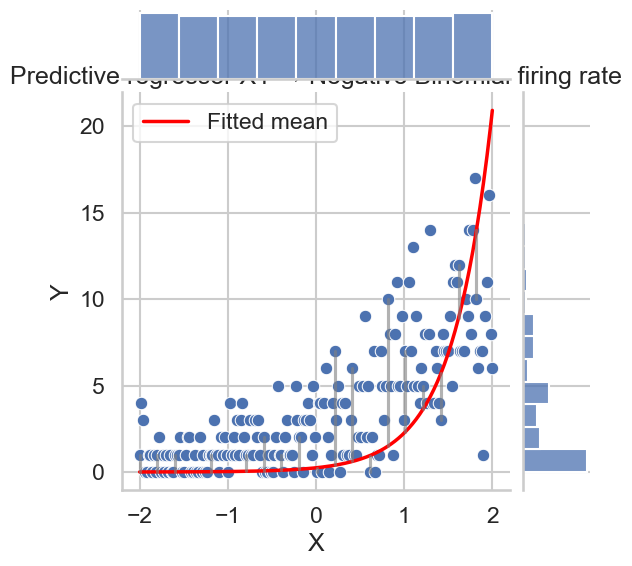

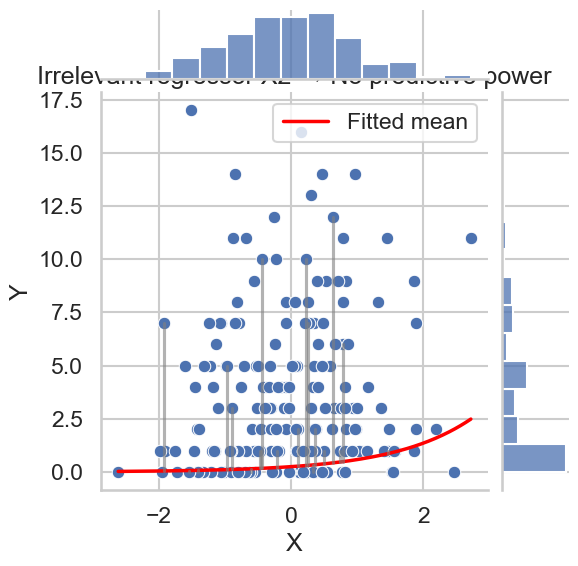

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import nbinom

# ==============================================================
# === SIMULATE DATA ============================================
# ==============================================================

np.random.seed(42)
n = 200

# Predictive regressor X1: correlated with rate
X1 = np.linspace(-2, 2, n)
# Irrelevant regressor X2: random noise
X2 = np.random.randn(n)

# True model parameters for X1
beta0, beta1 = 1.0, 0.8

# Mean firing rate (Poisson rate λ or mean of NegBin)
mu_true = np.exp(beta0 + beta1 * X1)

# Dispersion parameter for negative binomial
r = 5.0  # larger r -> closer to Poisson
p = r / (r + mu_true)

# Draw negative binomial counts
Y = nbinom(n=r, p=p).rvs()

# ==============================================================
# === FIT SIMPLE MODELS ========================================
# ==============================================================

# Fit 1: model Y ~ X1 (predictive)
X1_design = np.vstack([np.ones(n), X1]).T
beta_hat1, _, _, _ = np.linalg.lstsq(X1_design, np.log(Y + 1e-6), rcond=None)
mu_hat1 = np.exp(X1_design @ beta_hat1)

# Fit 2: model Y ~ X2 (irrelevant)
X2_design = np.vstack([np.ones(n), X2]).T
beta_hat2, _, _, _ = np.linalg.lstsq(X2_design, np.log(Y + 1e-6), rcond=None)
mu_hat2 = np.exp(X2_design @ beta_hat2)


def plot_joint_plotly(X, Y, mu_hat, title):
    """Plot scatter, fitted mean curve, and sampled residual sticks with Plotly."""
    fig = make_subplots(rows=1, cols=1)

    fig.add_trace(
        go.Scatter(
            x=X,
            y=Y,
            mode="markers",
            marker=dict(size=6, color="rgba(70,70,70,0.6)"),
            name="Samples",
        )
    )

    X_sorted = np.linspace(float(np.min(X)), float(np.max(X)), 200)
    mu_sorted = np.exp(np.polyval(np.polyfit(X, np.log(mu_hat + 1e-6), 1), X_sorted))
    fig.add_trace(
        go.Scatter(
            x=X_sorted,
            y=mu_sorted,
            mode="lines",
            line=dict(color="red", width=2),
            name="Fitted mean",
        )
    )

    for i in range(0, len(X), 10):
        fig.add_trace(
            go.Scatter(
                x=[X[i], X[i]],
                y=[mu_hat[i], Y[i]],
                mode="lines",
                line=dict(color="rgba(120,120,120,0.5)", width=1),
                showlegend=False,
                hoverinfo="skip",
            )
        )

    fig.update_layout(
        title=title,
        xaxis_title="Regressor",
        yaxis_title="Count",
        template="plotly_white",
        width=900,
        height=500,
    )
    fig.show()


# ==============================================================
# === VISUALIZE ================================================
# ==============================================================

plot_joint_plotly(X1, Y, mu_hat1, "Predictive regressor X1 -> Negative Binomial firing rate")
plot_joint_plotly(X2, Y, mu_hat2, "Irrelevant regressor X2 -> No predictive power")


In [ ]:

# do the same for PCA and ensembles

